# Balloon-v1 Model Demos

In this page, we demonstrate the usage of the Balloon-v1 model.

## Utilities

We need to run example analyses and extract and plot the generated results.
This would require some utilities to be at hand.


In [10]:
import os
import shutil
import subprocess
from tempfile import TemporaryDirectory
from time import sleep

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

plt.rcParams.update({"font.size": 6})

if os.name == "nt":
    raise RuntimeError

SUANPAN_EXE = "suanpan"
if shutil.which(SUANPAN_EXE) is None:
    raise RuntimeError("suanPan not found.")


def run_model(model: str, print_result: bool = False):
    with open("example.sp", "w") as file:
        file.write(model)
    result = subprocess.run(
        [SUANPAN_EXE, "-f", "example.sp"], capture_output=True, text=True
    )
    if print_result or "[ERROR]" in result.stdout:
        print(result.stdout)


COUNTER = 1


def gplot(x, y, *, cmap=None, color=None, linewidth=1, size=(6, 4), scatter=False):
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.arange(len(x))

    points = np.array([x, y]).T.reshape(-1, 1, 2)

    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    if cmap:
        lc = LineCollection(
            segments,  # type: ignore
            cmap=cmap,
            linewidth=linewidth,
            norm=Normalize(z.min(), z.max()),
        )
    else:
        lc = LineCollection(segments, colors=color, linewidth=linewidth)  # type: ignore
    lc.set_array(z)

    global COUNTER
    COUNTER += 1
    fig = plt.figure(COUNTER, size, layout="tight")
    ax = fig.gca()
    ax.grid(True, linestyle="--", linewidth=0.5)
    if scatter:
        ax.scatter(x, y, 2, color)
    else:
        ax.add_collection(lc)
    ax.autoscale()
    ax.set_xlabel("strain")
    ax.set_ylabel("stress")

    return fig, ax


class AutoSwitch(TemporaryDirectory):
    def __init__(self, *args, **kwargs):
        self.model = kwargs.pop("model")
        self.print_result = kwargs.pop("print_result", False)
        super().__init__(*args, **kwargs)
        self._old_cwd = None

    def __enter__(self):
        self._old_cwd = os.getcwd()
        target = super().__enter__()
        os.chdir(target)
        run_model(self.model, self.print_result)
        return target

    def __exit__(self, exc_type, exc_value, traceback):
        if self._old_cwd is not None:
            sleep(1)
            os.chdir(self._old_cwd)
        return super().__exit__(exc_type, exc_value, traceback)


model = """node 1 0 0
node 2 1 0

{material}

element T2D2 1 1 2 1 1

plainrecorder 1 Element HIST 1
plainrecorder 2 Element S 1
plainrecorder 3 Element E 1

fix2 1 1 1
fix2 2 2 1 2

expression SimpleScalar 1 t {amplitude}

amplitude Custom 3 1

disp 1 3 2 1 2

step static 1 {duration}
set fixed_step_size 1
set ini_step_size 2E-3
set symm_mat 0

converger RelIncreDisp 1 1E-10 10 1

analyze

save recorder 1 2 3

exit"""

## Stiffness Degradation

The function $u$ controls the evolution of the normal yield ratio $z$, it can decrease with the accumulation of plastic strain by assigning a negative saturation and a proper saturation rate.
The following example compares the non-degrading and a degrading cases.

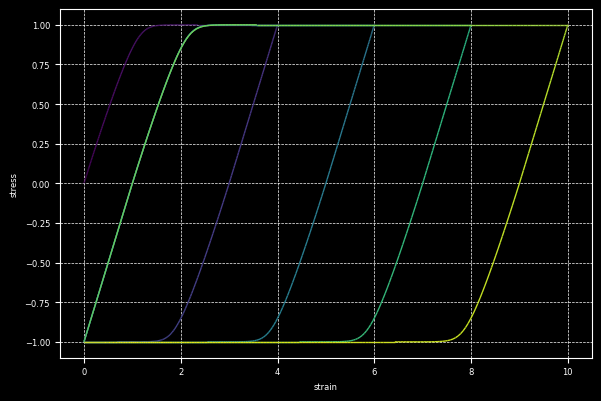

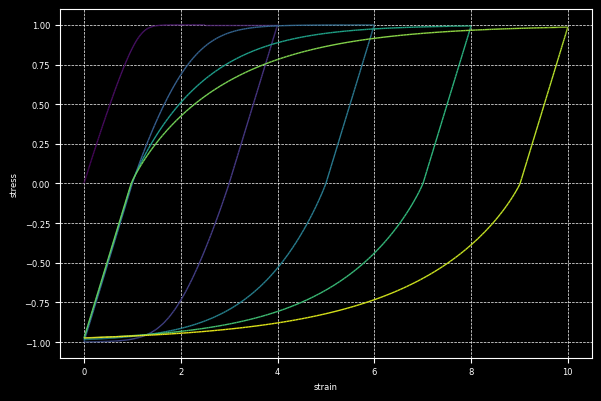

In [11]:
for rate in (0, 0.4):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 10 \
1E1 0 -1E1 {rate} \ ! u
1 1e-8 0 0 \ ! hfm
0 0 0 0 \ ! hfc
0 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 ! density""",
                amplitude="t<1?1-cos(2pi*t):t<2?1.5-1.5*cos(2pi*t):t<3?2-2cos(2pi*t):t<4?2.5-2.5cos(2pi*t):3-3cos(2pi*t)",
                duration=4,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Basic Isotropic Hardening

By controlling $f_m$, the isotropic hardening behaviour is similar to the conventional understanding.
The following examples adopt a linear hardening base with an optional saturation component.
Note that this type of exponential saturation (of isotropic hardening) is rarely useful as it saturates only once since plasticity accumulate is not reversible.

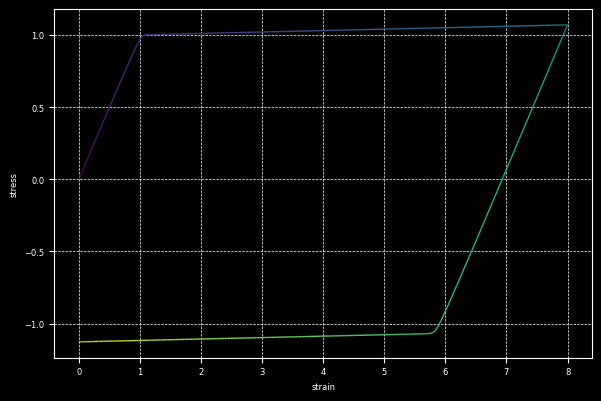

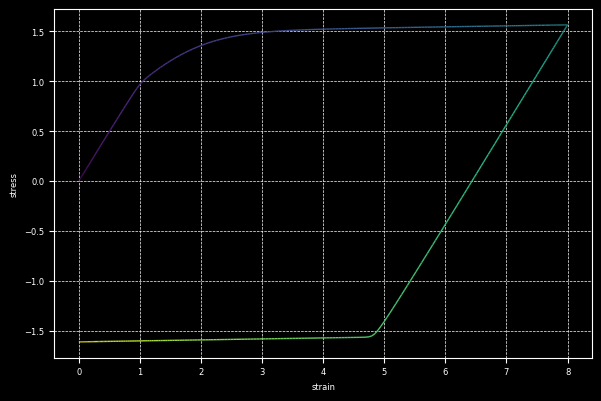

In [12]:
for rate in (0, 2):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 10 \
1E2 0 0 0 \ ! u
1 1e-2 .5 {rate} \ ! hfm
0 0 0 0 \ ! hfc
0 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 ! density""",
                amplitude="2-2cos(2pi*t)",
                duration=1,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Basic Kinematic Hardening

The similar bound for kinematic hardening is controlled by $a_m$.
However, to activate kinematic hardening, at least one pair of `-na` AF-type rule is needed.

**If rate is zero, it becomes a linear type rule.**

The following example presents three cases:

1. kinematic hardening deactivated,
2. a linear kinematic hardening rule,
3. a AF type exponential saturation rule.

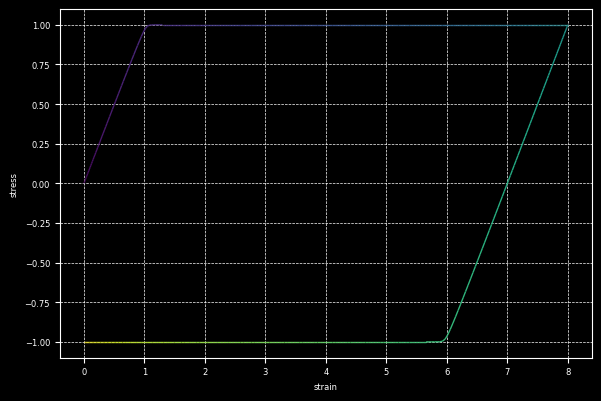

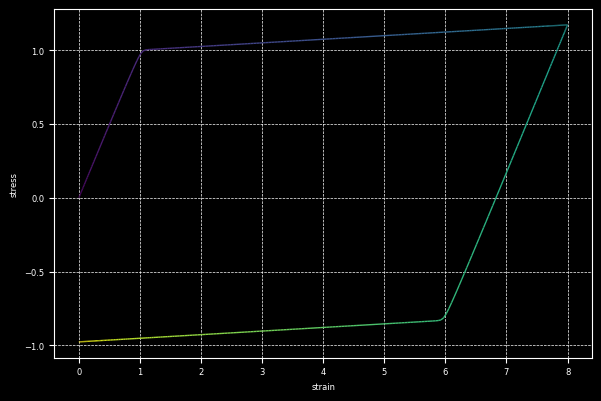

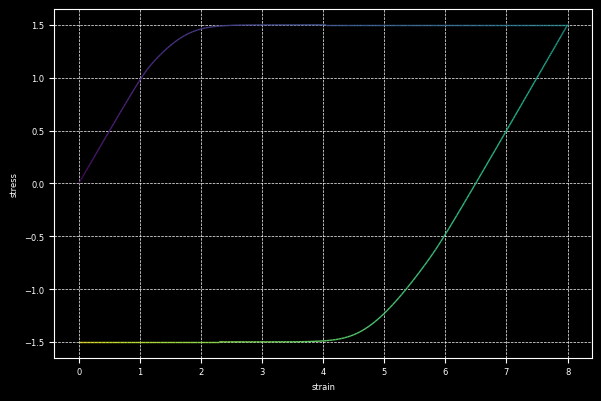

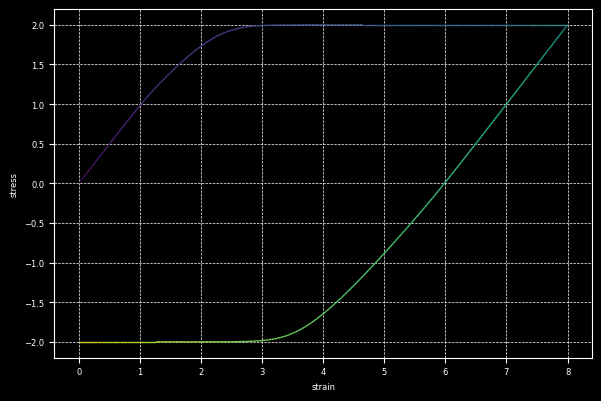

In [13]:
for saturation, rate in ((0, 0), (0.05, 0), (1, 5), (2, 5)):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 10 \
1E2 0 0 0 \ ! u
1 1e-8 0 0 \ ! hfm
0 0 0 0 \ ! hfc
.5 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 \ ! density
-na {saturation} {rate}""",
                amplitude="2-2cos(2pi*t)",
                duration=1,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Growing Kinematic Hardening Bound

The back stress can saturate to a bound, this bound can evolve as well.

Instead of using a combination of an AF rule and a linear rule for `-na`, one can allow $a_m$ to evolve.
The following example adds an linear component to $a_m$.

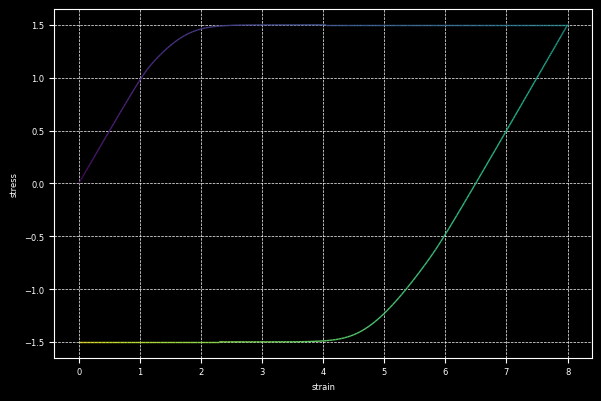

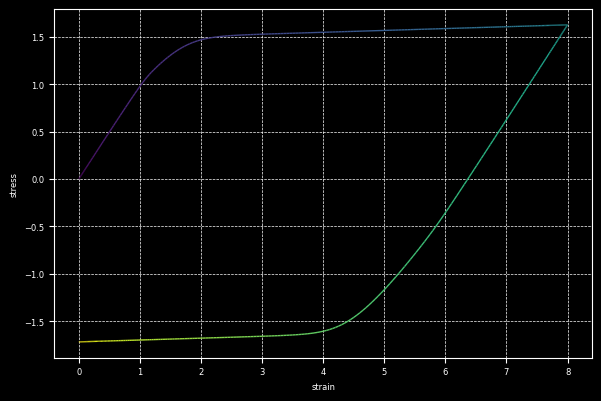

In [14]:
for linear in (0, 2e-2):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 10 \
1E2 0 0 0 \ ! u
1 1e-8 0 0 \ ! hfm
0 0 0 0 \ ! hfc
.5 {linear} 0 0 \ ! ham
0 0 0 0 \ ! hac
0 \ ! density
-na 1 5""",
                amplitude="2-2cos(2pi*t)",
                duration=1,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Further Enhancement Bauschinger Effect

At least one pair of non-trivial `-nd` sets would enable the transition of the subloading surface within the yield surface.
This will allow early re-yielding when reversely loaded.

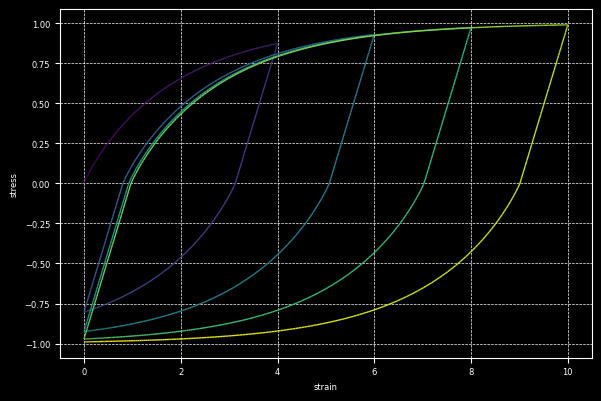

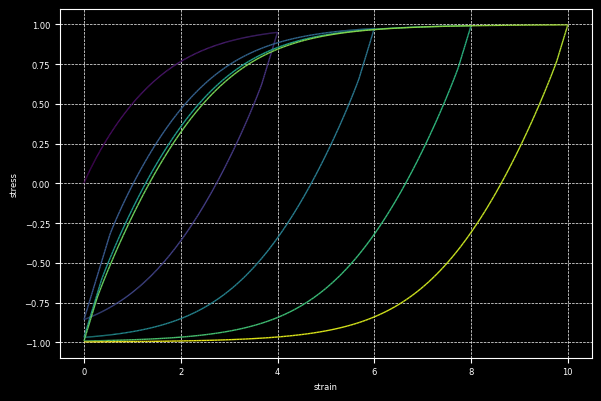

In [15]:
for saturation, rate in (
        (0, 5e-1),
        (0.8, 5e-1),
):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 10 \
5E-1 0 0 0 \ ! u
1 1e-8 0 0 \ ! hfm
0 0 0 0 \ ! hfc
0 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 \ ! density
-nd {saturation} {rate}""",
                amplitude="t<1?1-cos(2pi*t):t<2?1.5-1.5*cos(2pi*t):t<3?2-2cos(2pi*t):t<4?2.5-2.5cos(2pi*t):3-3cos(2pi*t)",
                duration=4,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Isotropic Hardening Stagnation

If $f_c$ is trivial, isotropic hardening will stagnate under cyclic loading.
This stagnation is the direct result of stagnation of accumulation of monotonic plastic strain.
This process is controlled by the memory size: the number of previous reverse points that are memorised.
The following example show the comparisons among memorising 1, 2 and 5 most recent reverse points.

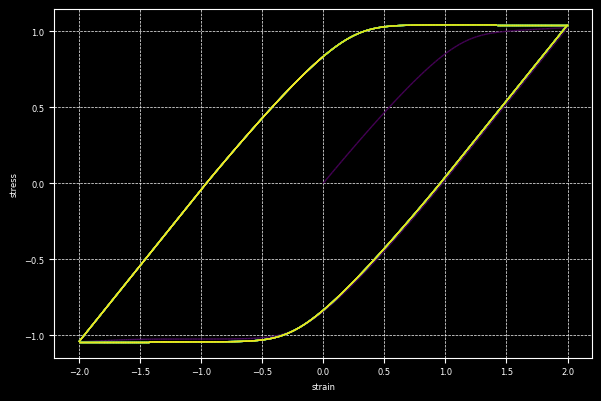

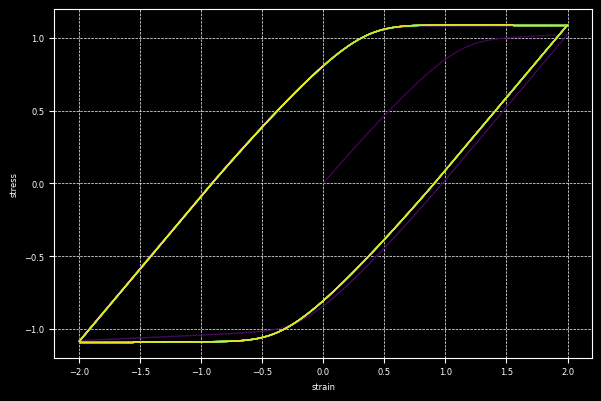

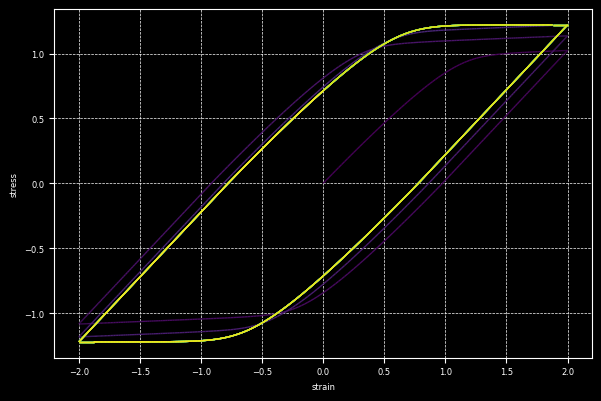

In [16]:
for memory in (1, 2, 5):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
    1 1E2 {memory} \
    1e1 0 0 0 \ ! u
    1 4e-2 0 0 \ ! hfm
    0 0 0 0 \ ! hfc
    0 0 0 0 \ ! ham
    0 0 0 0 \ ! hac
    0 ! density""",
                amplitude="sin(2pi*t)",
                duration=20,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Cyclic Isotropic Hardening/Softening

Although the accumulation of monotonic plastic strain is halted, the corresponding information is not lost.
Instead, the total increment of plastic strain is stored largely in the so called cyclic part during this cyclic phase.
This part of plastic strain drives a separate bound controlled by $f_c$.
A non-trivial bound shall be accompanied by at least one pair of valid `-fc` rule.

This mechanism can be used to simulate cyclic hardening/softening by defining a positive/negative evolving bound.

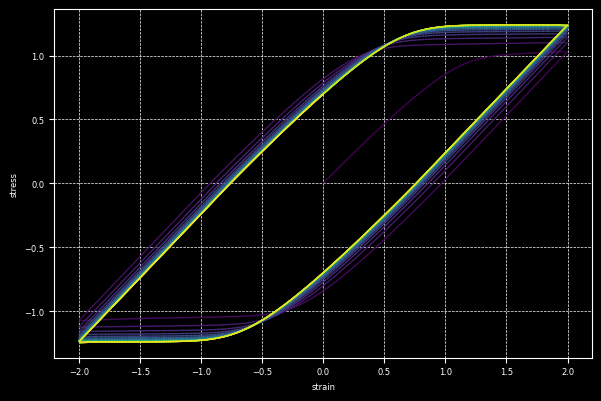

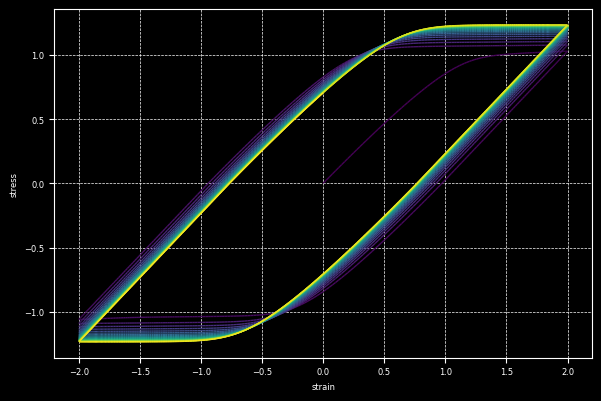

In [17]:
for rate in (1e-1, 5e-2):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 1 \
1e1 0 0 0 \ ! u
1 4e-2 0 0 \ ! hfm
.2 0 0 0 \ ! hfc
0 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 \ ! density
-fc 1 {rate}""",
                amplitude="sin(2pi*t)",
                duration=20,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

Because the bound itself is evolving with the development of plasticity, this cyclic hardening/softening can occur repeatedly under certain conditions.

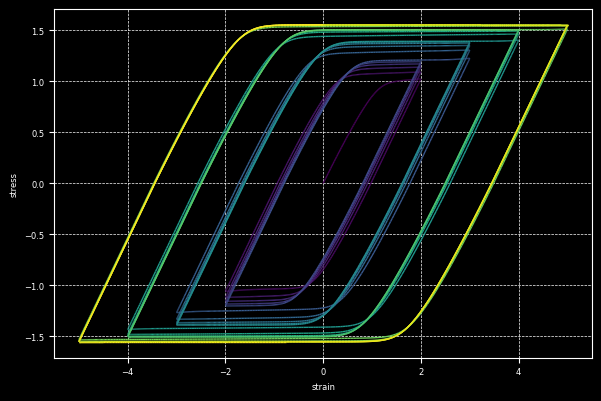

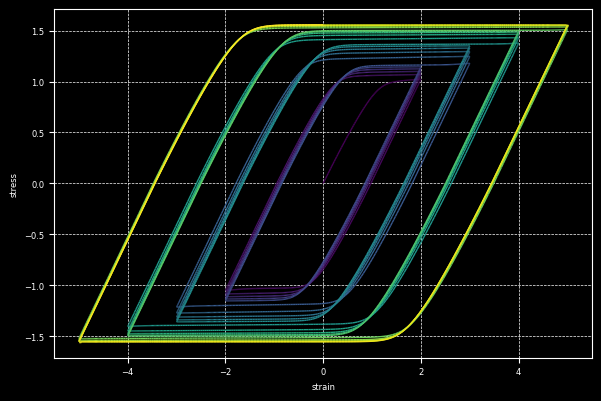

In [18]:
for rate in (1e-1, 5e-2):
    with AutoSwitch(
            model=model.format(
                material=rf"""material Balloon1D 1 \
1 1E2 1 \
1e1 0 0 0 \ ! u
1 4e-2 0 0 \ ! hfm
0 2e-1 0 0 \ ! hfc
0 0 0 0 \ ! ham
0 0 0 0 \ ! hac
0 \ ! density
-fc 1 {rate}""",
                amplitude="t<5?sin(2pi*t):t<10?1.5sin(2pi*t):t<15?2sin(2pi*t):2.5sin(2pi*t)",
                duration=20,
            )
    ):
        gplot(np.loadtxt("R3-E1.txt")[:, 1], np.loadtxt("R2-S1.txt")[:, 1])

## Cyclic Kinematic Hardening/Softening

The counterpart of such a monotonic/cyclic split is also available for kinematic hardening.
It is possible to define a non-trivial $a_c$ part with a valid `-ac` rule, and most likely, also with a valid `-na` rule.

However, since kinematic hardening is likely cyclic anyway, such an evolution of bound does not have many practical implications apart from constraining the size of back stress being a constant portion of that of the yield surface (isotropic hardening).
Nevertheless, it provides extra flexibility that may be useful for curve fitting.